<a href="https://colab.research.google.com/github/MoEissa140/FlyRank-Intern/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MoEissa140/FlyRank-Intern/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
!pip install -q huggingface_hub duckdb
import duckdb, os, pandas as pd
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"""
CREATE SECRET hf_token (
    TYPE huggingface,
    TOKEN '{os.environ["HF_TOKEN"]}'
);
""")

base = "hf://datasets/FlyRank/internship-warehouse"

feature_vector = con.sql(f"""
WITH feat_window AS (
    SELECT
        content_hash_id,
        client_hash_id,
        AVG(gsc_impressions) AS avg_impressions,
        AVG(gsc_clicks) AS avg_clicks,
        AVG(gsc_avg_position) AS avg_position,
        SUM(ga4_engaged_sessions) * 1.0 / NULLIF(SUM(ga4_sessions), 0) AS engagement_rate,
        SUM(scroll_events) * 1.0 / NULLIF(SUM(ga4_pageviews), 0) AS scroll_rate
    FROM read_parquet('{base}/fact_content_daily_performance/month=2026-03/data_0.parquet')
    GROUP BY content_hash_id, client_hash_id
),
target_window AS (
    SELECT
        content_hash_id,
        AVG(gsc_impressions) AS avg_impressions_next
    FROM read_parquet('{base}/fact_content_daily_performance/month=2026-04/data_0.parquet')
    GROUP BY content_hash_id
)
SELECT
    f.*,
    CASE WHEN t.avg_impressions_next < f.avg_impressions THEN 1 ELSE 0 END AS is_declining_label
FROM feat_window f
JOIN target_window t USING (content_hash_id)
WHERE f.avg_impressions > 0
""").df()

feature_vector["engagement_rate"] = feature_vector["engagement_rate"].fillna(0)
feature_vector["scroll_rate"] = feature_vector["scroll_rate"].fillna(0)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
from sklearn.model_selection import GroupKFold

# Reuse feature_vector from w03_feature_leakage_check.ipynb (Mar features -> Apr label)
X_cols = ["avg_impressions","avg_clicks","avg_position","engagement_rate","scroll_rate"]
X = feature_vector[X_cols].fillna(0)
y = feature_vector["is_declining_label"]
groups = feature_vector["client_hash_id"]

gkf = GroupKFold(n_splits=5)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

# Out-of-fold predictions: each row's prediction comes from a fold that never trained on it
oof_probs = cross_val_predict(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    X, y, cv=gkf, groups=groups, method="predict_proba"
)[:, 1]

feature_vector["predicted_decline_prob"] = oof_probs

In [ ]:
# Reason codes: combine model score with the interpretable baseline logic from w04
def assign_reason_code(row):
    if row["predicted_decline_prob"] >= 0.65 and row["avg_impressions"] >= 500:
        return "high_risk_visible_page"
    elif row["predicted_decline_prob"] >= 0.65:
        return "model_decline_risk"
    elif row["avg_position"] > 20 and row["avg_impressions"] >= 100:
        return "page_buried_with_demand"
    else:
        return "monitor"

feature_vector["reason_code"] = feature_vector.apply(assign_reason_code, axis=1)
feature_vector["action"] = feature_vector["reason_code"].map({
    "high_risk_visible_page": "review_for_refresh",
    "model_decline_risk": "review_for_refresh",
    "page_buried_with_demand": "review_snippet_and_position",
    "monitor": "monitor"
})

ranked_queue = feature_vector.sort_values("predicted_decline_prob", ascending=False)
ranked_queue[["content_hash_id","predicted_decline_prob","avg_impressions","avg_position","reason_code","action"]].head(20)

,content_hash_id,predicted_decline_prob,avg_impressions,avg_position,reason_code,action
50374,content_fca3a3fd6b0abf93,1.0,0.032258,34.000000,model_decline_risk,review_for_refresh
138021,content_e027161df1a8f081,1.0,0.129032,7.333333,model_decline_risk,review_for_refresh
49862,content_4683663e68b91c53,1.0,0.129032,2.666667,model_decline_risk,review_for_refresh
49935,content_d8ca54fa399594b2,1.0,0.129032,2.666667,model_decline_risk,review_for_refresh
50516,content_edab224b23eea26b,1.0,0.129032,7.333333,model_decline_risk,review_for_refresh
145551,content_5ab2837336838e56,1.0,0.419355,7.905556,model_decline_risk,review_for_refresh
47631,content_79df0fb7300dcf24,1.0,0.193548,12.000000,model_decline_risk,review_for_refresh
172357,content_bdc5dcab9bf74f8b,1.0,0.225806,3.750000,model_decline_risk,review_for_refresh
106274,content_dc9b90306cbde847,1.0,0.032258,58.000000,model_decline_risk,review_for_refresh
18903,content_8e108821d71d8cac,1.0,0.032258,70.000000,model_decline_risk,review_for_refresh


**Ranked queue logic:** pages are ordered by the model's predicted decline probability. Each row gets one reason code a reviewer can trust at a glance:
- `high_risk_visible_page` — high predicted decline risk AND real traffic at stake (≥500 impressions) → highest priority
- `model_decline_risk` — high predicted decline risk but lower current visibility → still worth a look
- `page_buried_with_demand` — not flagged as declining by the model, but sitting past position 20 with real demand (≥100 impressions) → a different kind of opportunity (visibility, not decline)
- `monitor` — no strong signal either way, no action needed now

This maps directly to the reason-code pattern established in Week 4's baseline, now driven by the validated model score instead of a single hand-written rule.

## 2. Intended use and limits

**Who uses this:** a content strategist or SEO reviewer doing weekly/biweekly prioritization — deciding which pages to look at first out of hundreds, not which pages are definitively broken.

**What it's for:** ranking review order under limited reviewer capacity (e.g. "which 20 pages do I check this week"), not a final verdict on any single page.

**Where it stops being valid:**
- The model's honest AUC (client-grouped validation, ML-09) was ~0.51 — barely above chance. This queue is a weak directional signal, not a confident prediction. Treat rank order as a rough triage aid, not a scorecard.
- Trained on March→April data for the observed client panel; predictions degrade for clients with very different traffic patterns, industries, or GA4 history than what's in this training window (per ML-04's coverage limit: only ~4% of rows have GA4 data, so `engagement_rate`/`scroll_rate` are unreliable for the majority of pages).
- Does not account for seasonality, planned campaigns, or upcoming site changes — a page "declining" during a known seasonal dip is a false positive this model cannot distinguish.
- Never validated as causal: nothing here proves that acting on a flagged page will fix it, only that similar pages historically behaved a certain way.

## 3. Human review + the no-go list

**Before acting on any flagged page, a human must check:**
- Is this a real, sustained decline, or a short blip / consolidation to a sibling page (per ML-06 Section 7 patterns)?
- Does the page belong to a client with thin GA4 history — if so, engagement-based reasoning behind the flag may be unreliable?
- Is there a known external cause (seasonality, a site migration, a competitor change) that explains the pattern better than "content needs refresh"?

**Should NEVER be automated:**
- Auto-publishing content changes based on the model score alone — this queue prioritizes *review*, not *action*.
- Treating `predicted_decline_prob` as a confidence percentage a stakeholder can quote externally — the model's honest AUC is too close to chance for that framing to be honest.
- Merging or deleting pages based solely on this ranking — that requires the consolidation check from ML-06, done by a human, every time.

## 4. Monitoring / retrain triggers

**Signs these recommendations have gone stale:**
- The honest (grouped) AUC drops meaningfully below the ~0.51 baseline established in ML-09 when re-measured on a newer month — indicates the pattern the model learned no longer holds.
- A large influx of new clients whose traffic profile differs substantially from the March 2026 training panel (new industries, very different GA4 coverage rates).
- The underlying `fact_content_daily_performance` schema changes (new columns, renamed fields) — confirmed this happens between snapshot versions (build ids differ), so any pipeline reuse should re-run the `DESCRIBE` check from ML-04 before trusting column names.
- Retrain cadence: monthly, using the same feature/label window shape (trailing-90-day features → next-30-day outcome), always re-validated with the client-grouped split — never the naive split.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Reproduce Week-4 baseline as a score
baseline_score = (feature_vector["avg_impressions"] >= 100).astype(int)
baseline_auc = roc_auc_score(y, baseline_score)

# Logistic Regression and Random Forest, evaluated honestly via GroupKFold (same as w05/w06)
def evaluate(model, X, y, groups):
    aucs = []
    for train_idx, test_idx in gkf.split(X, y, groups):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        proba = model.predict_proba(X.iloc[test_idx])[:, 1]
        aucs.append(roc_auc_score(y.iloc[test_idx], proba))
    return sum(aucs) / len(aucs)

lr_auc = evaluate(LogisticRegression(max_iter=1000), X, y, groups)
rf_auc = evaluate(RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1), X, y, groups)

# naive vs grouped comparison from w06
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
naive_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_train, y_train)
naive_auc = roc_auc_score(y_test, naive_model.predict_proba(X_test)[:, 1])
grouped_auc = rf_auc  # same GroupKFold RF result computed above

In [ ]:
best_model_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X, y)
importances = pd.Series(best_model_full.feature_importances_, index=X_cols).sort_values(ascending=False)
importances

,0
avg_position,0.522144
avg_impressions,0.352333
avg_clicks,0.062208
scroll_rate,0.044713
engagement_rate,0.018602


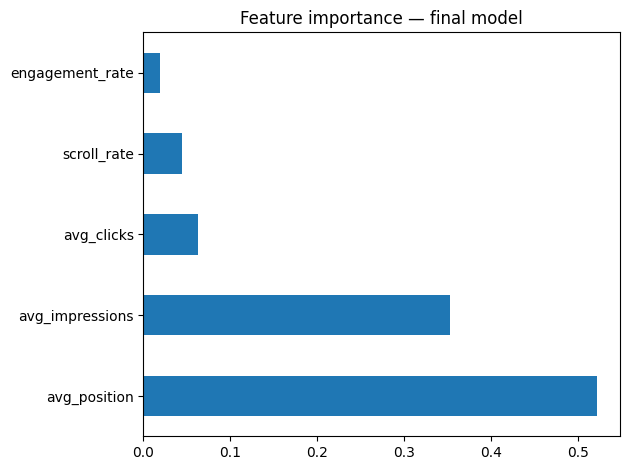

In [ ]:
import os
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the ranked queue (CSV stays out of git by design — CI leak-guard)
ranked_queue[["content_hash_id","predicted_decline_prob","avg_impressions","avg_position","reason_code","action"]].to_csv(
    "work/outputs/final_action_queue.csv", index=False
)

# Export metrics as JSON (this DOES get committed — it's your paper's receipts)
import json
metrics = {
    "baseline_auc": float(baseline_auc),
    "logistic_regression_auc": float(lr_auc),
    "random_forest_auc": float(rf_auc),
    "naive_split_auc": float(naive_auc),
    "grouped_split_auc": float(grouped_auc),
    "feature_importance": importances.to_dict()
}
with open("work/outputs/final_model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# Save a figure to reuse in the paper
import matplotlib.pyplot as plt
importances.plot(kind="barh")
plt.title("Feature importance — final model")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.